In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.2)

# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.sans-serif": ["Optima", "Helvetica", "Arial"],
#     "font.size": 11 # Match your paper's body text size
# })

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

In [2]:
# from matplotlib import font_manager
# font_manager.get_font_names()

In [3]:
extracted_df = pd.read_json("../code/outputs/extracted_text/qwen3_thinking-4B/extracted_interventions_conditions_with_simplified.json")
extracted_questions_df = pd.read_json("../code/outputs/questions/qwen3_thinking-4B/extracted/cochrane_review_data_final_with_questions.json")
simplified_questions_df = pd.read_json("../code/outputs/questions/qwen3_thinking-4B/simplified/cochrane_review_data_final_with_questions.json")

In [4]:
print(f"number of reviews (total) after term extraction: {len(extracted_df)}")
print(f"number of reviews after question generation (extracted): {len(extracted_questions_df)}")

print(f"number of reviews after question generation (simplified): {len(simplified_questions_df)}")

number of reviews (total) after term extraction: 629
number of reviews after question generation (extracted): 368
number of reviews after question generation (simplified): 363


## By Number of Included Studies

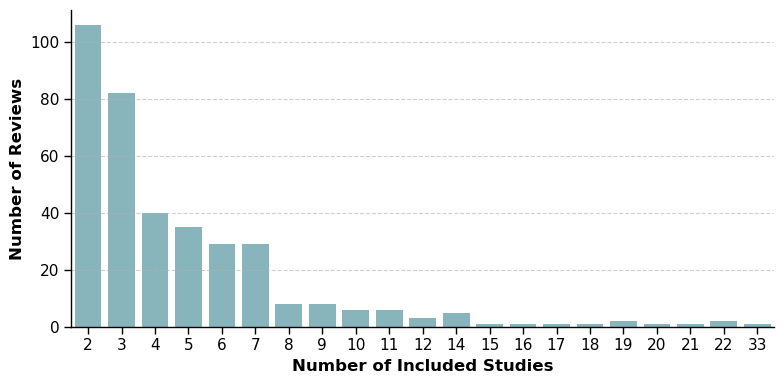

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(data=extracted_questions_df, x='NumInputs', color='#7fbbc5')
sns.despine()

# Customizing the chart for readability
# plt.title('Distribution of Reviews by Number of Included Studies', fontsize=15)
plt.xlabel('Number of Included Studies', fontweight='bold', fontsize=12)
plt.ylabel('Number of Reviews', fontweight='bold', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../code/outputs/figures/review_distribution_by_num_studies.pdf', format='pdf')

plt.show()

## By Review Publication Year

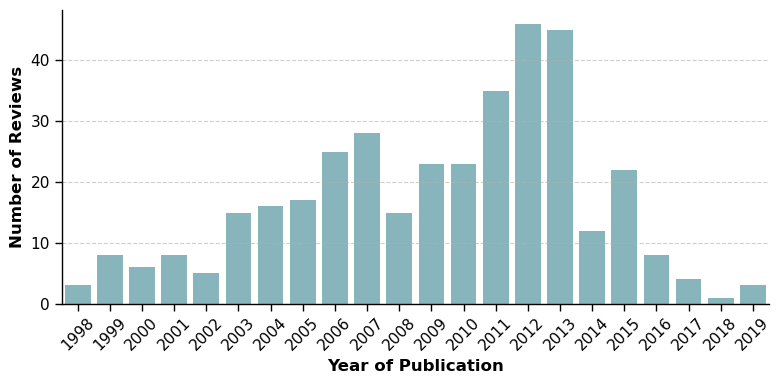

In [6]:
plt.figure(figsize=(8, 4))
sns.countplot(data=extracted_questions_df, x='Year', color='#7fbbc5')
sns.despine()

# Customizing the chart for readability
# plt.title('Distribution of Reviews by Year', fontsize=15)
plt.xlabel('Year of Publication', fontweight='bold', fontsize=12)
plt.ylabel('Number of Reviews', fontweight='bold', fontsize=12)
plt.xticks(rotation=45)  # Rotate labels if you have many years
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../code/outputs/figures/review_distribution_by_year.pdf', format='pdf')

plt.show()

## By Condition Categories

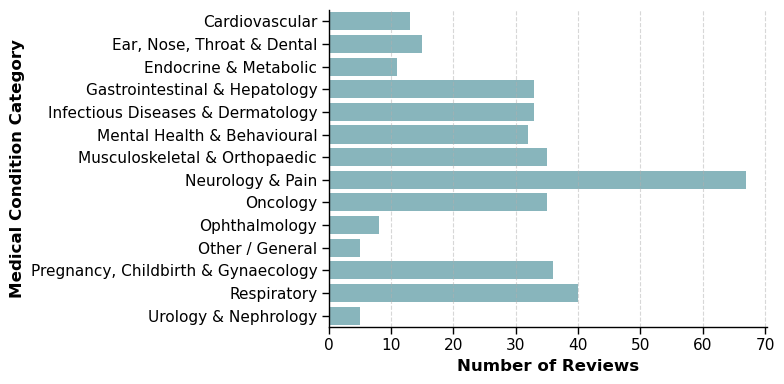

In [19]:
plt.figure(figsize=(8, 4))

unique_categories = extracted_questions_df['ConditionCategory'].unique()
# Sort them alphabetically
sorted_categories = sorted(unique_categories)

sns.countplot(data=extracted_questions_df, y='ConditionCategory', color='#7fbbc5', orient='h', order=sorted_categories)
sns.despine()

# Customizing the chart for readability
# plt.title('Distribution of Reviews by Condition Category', fontsize=15)
plt.ylabel('Medical Condition Category', fontweight='bold', fontsize=12)
plt.xlabel('Number of Reviews', fontweight='bold', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../code/outputs/figures/review_distribution_by_condition_category.pdf', format='pdf')

plt.show()

## By Question Jargon Score

Default (extracted) questions vs Simplified

In [8]:
def get_med_jargon_scores(df):
    # get the average MedReadMe scores across all reviews
    all_scores = []
    for _, row in df.iterrows():
        medreadme_scores = row["MedReadMeScores"]
        scores_from_all_categories = []
        for _, scores in medreadme_scores.items():
            positive_score = scores["positive_question"]
            negative_score = scores["negative_question"]
            pair_avg_score = (positive_score + negative_score) / 2
            scores_from_all_categories.append(pair_avg_score)
        all_scores.append(sum(scores_from_all_categories) / len(scores_from_all_categories) if scores_from_all_categories else 0)
    return all_scores

In [9]:
extracted_questions_scores = get_med_jargon_scores(extracted_questions_df)
simplified_questions_scores = get_med_jargon_scores(simplified_questions_df)

In [10]:
print(f"length of extracted questions scores: {len(extracted_questions_scores)}")
print(f"length of simplified questions scores: {len(simplified_questions_scores)}")

length of extracted questions scores: 368
length of simplified questions scores: 363


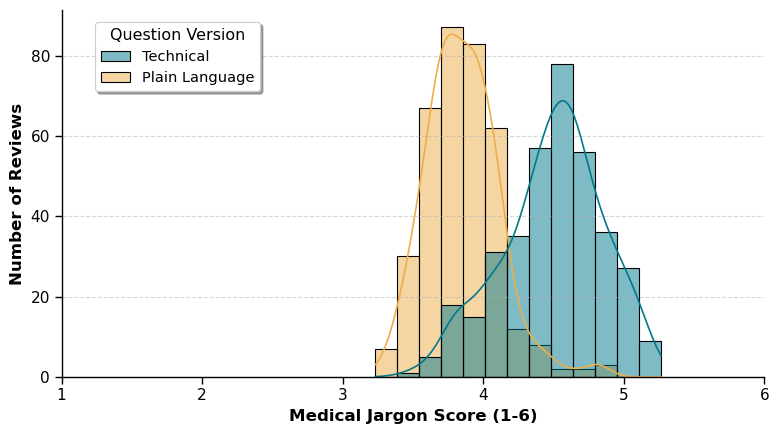

In [20]:
# Create a combined DataFrame
df = pd.DataFrame({
    'Score': extracted_questions_scores + simplified_questions_scores,
    'Question Version': ['Technical']*len(extracted_questions_scores) + ['Plain Language']*len(simplified_questions_scores)
})

# Now use the displot as shown above
g = sns.displot(data=df, x="Score", hue="Question Version", kde=True, palette=['#00798C', '#EDAE49'], 
                height=4.5,      # Adjust this for vertical size
                aspect=1.4     # Adjust this for horizontal stretch)
)

# plt.title("Comparison of Medical Jargon Score Distributions")
plt.ylabel('Number of Reviews', fontweight='bold', fontsize=12)
plt.xlabel('Medical Jargon Score (1-6)', fontweight='bold', fontsize=12)
plt.xlim(1, 6) # Sets the x-axis from 1 to 6
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.move_legend(
    g, "upper left", 
    bbox_to_anchor=(0.12, 0.95),  # Fine-tune the (x, y) position inside the axes
    frameon=True,                 # This creates the "box"
    shadow=True,                  # Optional: adds a slight shadow for depth
    title='Question Version'
)

plt.tight_layout()
plt.savefig('../code/outputs/figures/review_distribution_by_medical_jargon.pdf', format='pdf')

plt.show()

In [12]:
print(f"Average MedReadMe (medical jargon) scores (range 1-6) across all reviews (extracted questions): {sum(extracted_questions_scores) / len(extracted_questions_scores):.2f}")
print(f"Average MedReadMe (medical jargon) scores (range 1-6) across all reviews (simplified questions): {sum(simplified_questions_scores) / len(simplified_questions_scores):.2f}")

Average MedReadMe (medical jargon) scores (range 1-6) across all reviews (extracted questions): 4.49
Average MedReadMe (medical jargon) scores (range 1-6) across all reviews (simplified questions): 3.85


In [13]:
import statistics
print(f"Median MedReadMe (medical jargon) scores (range 1-6) across all reviews (extracted questions): {statistics.median(extracted_questions_scores)}")
print(f"Median MedReadMe (medical jargon) scores (range 1-6) across all reviews (simplified questions): {statistics.median(simplified_questions_scores)}")

Median MedReadMe (medical jargon) scores (range 1-6) across all reviews (extracted questions): 4.51780863908621
Median MedReadMe (medical jargon) scores (range 1-6) across all reviews (simplified questions): 3.83280211687088


In [14]:
from scipy import stats

def determine_and_run_test(data1, data2):
    # --- STEP 1: TEST FOR NORMALITY (Shapiro-Wilk) ---
    # Null Hypothesis: Data is normally distributed
    _, p_norm1 = stats.shapiro(data1)
    _, p_norm2 = stats.shapiro(data2)
    
    is_normal = p_norm1 > 0.05 and p_norm2 > 0.05
    
    # --- STEP 2: TEST FOR EQUAL VARIANCE (Levene's Test) ---
    # Null Hypothesis: Variances are equal
    _, p_var = stats.levene(data1, data2)
    equal_variance = p_var > 0.05

    print(f"Normality Check: {'Passed' if is_normal else 'Failed (p<0.05)'}")
    print(f"Variance Check: {'Equal' if equal_variance else 'Unequal (p<0.05)'}")
    print("-" * 30)

    # --- STEP 3: RUN THE APPROPRIATE TEST ---
    if is_normal:
        # Use T-Test (Parametric)
        # alternative='greater' tests if group_a is significantly GREATER than group_b
        result = stats.ttest_ind(data1, data2, 
                                        equal_var=equal_variance, 
                                        alternative='greater')
        test_name = "Welch's T-test" if not equal_variance else "Student's T-test"
    else:
        # Use Mann-Whitney U (Non-Parametric)
        # alternative='greater' tests if distribution of a is stochastically greater than b
        result = stats.mannwhitneyu(data1, data2, alternative='greater')
        test_name = "Mann-Whitney U Test"

    print(f"Result using {test_name}:")
    print(f"P-value: {result.pvalue:.6f}")

    if result.pvalue < 0.05:
        print("Conclusion: Statistically significant. Group A is greater than Group B.")
    else:
        print("Conclusion: Not significant. No evidence that Group A is greater than Group B.")

    if is_normal:
        print(f"T-statistic: {result.statistic}")
    else:
        print(f"U-statistic: {result.statistic}")
        # get Z-score for Mann-Whitney U
        n1 = len(data1)
        n2 = len(data2)
        u_stat = result.statistic
        mean_u = n1 * n2 / 2
        std_u = ((n1 * n2 * (n1 + n2 + 1)) / 12) ** 0.5
        z_score = (u_stat - mean_u) / std_u
        print(f"Z-score for Mann-Whitney U: {z_score:.4f}")

# Execute
determine_and_run_test(extracted_questions_scores, simplified_questions_scores)

Normality Check: Failed (p<0.05)
Variance Check: Unequal (p<0.05)
------------------------------
Result using Mann-Whitney U Test:
P-value: 0.000000
Conclusion: Statistically significant. Group A is greater than Group B.
U-statistic: 122471.0
Z-score for Mann-Whitney U: 19.5051
